# Bean there done that — CRISP-DM Phase 2: Data Understanding

**Course:** Storytelling with Data (minor Data Driven Decision Making, HAN)
**Client:** CEO of Bean there done that
**Main question (from the Business Understanding):** *Is Bean there done that ready to grow again from next year, and which bottlenecks must be solved first?*

In this notebook we explore the dataset using the four tasks of CRISP-DM phase 2:

1. **Collect initial data** — what data do we have and how is it structured?
2. **Describe data** — what do the columns mean, and which units and codes are used?
3. **Verify data quality** — is the data correct, is anything missing, and do the sheets match each other?
4. **Explore data** — first patterns per business process (sourcing → roasting → stock → sales → delivery), as a basis for KPIs.

**Working rule:** before each step we explain what we will do and why. After each output we explain what it means for the CEO's decision and what the next step is.

> Put `Bean_there_done_that_data.xlsx` in the same folder as this notebook.

## 0. Setup

**What:** we load the standard libraries (pandas, numpy, matplotlib, seaborn) and set fixed colours for each roast type and each machine.
**Why:** with fixed colours, the same colour means the same thing in every chart (Dark Roast is always blue). This saves work later in the storytelling part.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Fixed colours: the same entity always gets the same colour
ROAST_COLORS = {'Dark Roast': '#2a78d6', 'Medium Roast': '#eb6834', 'Light Roast': '#1baf7a'}
MACHINE_COLORS = {'Probat P60': '#2a78d6', 'Probat Px120': '#eb6834'}
GREY = '#898781'
ROASTS = ['Dark Roast', 'Medium Roast', 'Light Roast']
MONTHS = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
          'August', 'September', 'October', 'November', 'December']
MONTH_ABBR = [m[:3] for m in MONTHS]

plt.rcParams.update({
    'figure.figsize': (10, 4.5), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GREY, 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
    'legend.frameon': False, 'lines.linewidth': 2,
})
thousands = mtick.FuncFormatter(lambda x, p: f'{x:,.0f}')

## 1. Collect initial data

### 1.1 Load all sheets
**What:** we read all tabs of the Excel file at once and show the number of rows and columns per sheet.
**Why:** we want to know which business processes are in the data and at what level of detail (per order, per month, per machine). Expectation: five sheets that together cover the chain sourcing → production → stock → sales.

In [2]:
FILE = 'Bean_there_done_that_data.xlsx'
sheets = pd.read_excel(FILE, sheet_name=None)

overview = pd.DataFrame({
    'sheet': list(sheets.keys()),
    'rows': [df.shape[0] for df in sheets.values()],
    'columns': [df.shape[1] for df in sheets.values()],
})
overview

,sheet,rows,columns
0,Inventory (raw material),72,10
1,Inventory (finished product),36,8
2,Roasting,36,15
3,E-com sales orders by product,240352,9
4,B2B orders,273,8


In [3]:
# Short names for the five sheets
raw_inv = sheets['Inventory (raw material)'].copy()
fin_inv = sheets['Inventory (finished product)'].copy()
roast   = sheets['Roasting'].copy()
ecom    = sheets['E-com sales orders by product'].copy()
b2b     = sheets['B2B orders'].copy()

overview['process step'] = ['Sourcing / raw material storage', 'Finished product storage',
                            'Roasting, cooling & packing', 'Sales & delivery (e-commerce)',
                            'Sales & delivery (B2B)']
overview['granularity'] = ['product x month', 'roast type x month', 'machine x roast type x month',
                           'one row per order line', 'one row per delivery']
overview

,sheet,rows,columns,process step,granularity
0,Inventory (raw material),72,10,Sourcing / raw material storage,product x month
1,Inventory (finished product),36,8,Finished product storage,roast type x month
2,Roasting,36,15,"Roasting, cooling & packing",machine x roast type x month
3,E-com sales orders by product,240352,9,Sales & delivery (e-commerce),one row per order line
4,B2B orders,273,8,Sales & delivery (B2B),one row per delivery


**Interpretation:** The dataset has five sheets that together cover the whole chain from the case: sourcing/raw materials (72 rows), roasting (36), finished product stock (36), e-commerce sales (240,352 order lines) and B2B deliveries (273). Only the sales data is at order level; production and stock are summarised per month. For the CEO this means we can analyse demand down to the day, but capacity and stock only per month. That is detailed enough for a growth decision, but not for daily planning. **Next step:** understand the columns in each sheet.

## 2. Describe data

### 2.1 First rows and data types per sheet
**What:** for each sheet we look at the first rows and the data types.
**Why:** this shows which columns are numeric, whether dates are read correctly, and which codes (such as `Bag type` and `Reasoncode`) we still need to decode.

In [4]:
for name, df in [('raw_inv', raw_inv), ('fin_inv', fin_inv), ('roast', roast), ('ecom', ecom), ('b2b', b2b)]:
    print(f'===== {name}  {df.shape} =====')
    display(df.head(3))
    print(df.dtypes.to_string(), '\n')

===== raw_inv  (72, 10) =====


,Product,Supplier,Month,Stock level,Unit,Scrapped,Reasoncode,Unit price,Stock value,Purchased
0,"Coffee bag w/valve 0,5",ProPack,January,100000,Piece,0,NaN,0.40,"40,000.00",0
1,"Coffee bag w/valve 0,5",ProPack,February,80000,Piece,0,NaN,0.40,"32,000.00",0
2,"Coffee bag w/valve 0,5",ProPack,March,60000,Piece,0,NaN,0.40,"24,000.00",0


Product            str
Supplier           str
Month              str
Stock level      int64
Unit               str
Scrapped         int64
Reasoncode         str
Unit price     float64
Stock value    float64
Purchased        int64 

===== fin_inv  (36, 8) =====


,Product,Month,Stock level,Unit,Scrapped,Reasoncode,Unit price,Stock value
0,Dark roast,January,18660,Kg,0,NaN,22.98,"428,806.80"
1,Dark roast,February,17290,Kg,0,NaN,22.98,"397,324.20"
2,Dark roast,March,27231,Kg,0,NaN,22.98,"625,768.38"


Product            str
Month              str
Stock level      int64
Unit               str
Scrapped         int64
Reasoncode         str
Unit price     float64
Stock value    float64 

===== roast  (36, 15) =====


...

Machine                               str
Month                                 str
Product type                          str
Workdays                            int64
Number of batches per day         float64
Load weight p/batch               float64
Final weight /pbatch              float64
Setup time p/batch                float64
Run time p/batch (m)              float64
Cooling time p/batch              float64
Packing time p/batch              float64
QC fail/ Weight                     int64
QC fail/ Color                      int64
QC fail/ Roast profile              int64
Total rejected batches p/month      int64 

===== ecom  (240352, 9) =====


,Product,Bag type,Quantity,Value,Order date,Delivery date,Delivery fee,Shipping costs,Ship to (province)
0,Dark Roast,2,11,126.39,2023-01-01,2023-01-02,0.00,6.75,Zuid-Holland
1,Dark Roast,2,6,68.94,2023-01-01,2023-01-02,0.00,6.75,Overijssel
2,Dark Roast,2,3,34.47,2023-01-01,2023-01-02,4.95,6.75,Limburg


Product                          str
Bag type                       int64
Quantity                       int64
Value                        float64
Order date            datetime64[us]
Delivery date         datetime64[us]
Delivery fee                 float64
Shipping costs               float64
Ship to (province)               str 

===== b2b  (273, 8) =====


,Customer,City,Product,Bag type,Quantity,Value,Delivery date,Shipping costs
0,NextGen Offices,Arnhem,Medium Roast,1,56,"1,450.40",2023-01-02,75
1,DevOffice,Rotterdam,Medium Roast,1,67,"1,735.30",2023-01-02,75
2,Rent-a-desk,Nijmegen,Medium Roast,1,45,"1,165.50",2023-01-02,75


Customer                     str
City                         str
Product                      str
Bag type                   int64
Quantity                   int64
Value                    float64
Delivery date     datetime64[us]
Shipping costs             int64 



**Interpretation:** Dates in the sales sheets are read directly as dates. The monthly sheets use the month name as text (`January` … `December`), so we need a month number to link them. Two things stand out: product names use different capital letters between sheets (`Dark roast` vs `Dark Roast`), and `Bag type` is a code (1/2) instead of a weight. Unless we fix this, we cannot compare sales (bags) with production and stock (kg). **Next step:** decode `Bag type`.

### 2.2 What does `Bag type` mean?
**What:** we calculate the price per bag (`Value / Quantity`) per product and `Bag type`.
**Why:** the case mentions bags of 500 g and 1 kg, but the data only uses the codes 1 and 2. If `Bag type` 2 costs exactly half of `Bag type` 1, we know which code belongs to which size. We need this to convert sales into kilograms, so we can compare sales with production and stock (also in kg).

In [5]:
ecom['price_per_bag'] = ecom['Value'] / ecom['Quantity']
bag_check = ecom.groupby(['Product', 'Bag type'])['price_per_bag'].agg(['min', 'max', 'count'])
bag_check

min   max  count
Product      Bag type                   
Dark Roast   1        22.98 22.98  32591
             2        11.49 11.49  75779
Light Roast  1        26.50 26.50  14475
             2        13.25 13.25  33584
Medium Roast 1        25.90 25.90  25143
             2        12.95 12.95  58780

In [6]:
# Same check for B2B, compared with the finished-product price per kg
b2b['price_per_bag'] = b2b['Value'] / b2b['Quantity']
print('B2B price per bag:', b2b['price_per_bag'].unique(), '| Bag type:', b2b['Bag type'].unique())
fin_inv.groupby('Product')['Unit price'].first()

B2B price per bag: [25.9 25.9 25.9] | Bag type: [1]


Product
Dark roast     22.98
Light roast    26.50
Medium roast   25.90
Name: Unit price, dtype: float64

**Interpretation:** The price per bag is completely constant for each combination (min = max). `Bag type` 2 costs exactly half of `Bag type` 1 (e.g. Dark Roast €11.49 vs €22.98), and the price of `Bag type` 1 equals the price per kg in the finished product stock (€22.98 / €25.90 / €26.50). So: **1 = 1 kg bag, 2 = 0.5 kg bag**. There is no price difference per kg between the bag sizes, and no discount for B2B (also €25.90 per kg). For the CEO this means the 0.5 kg bag does not earn a higher margin per kg, while it needs twice as much packaging and packing time per kg. **Next step:** convert all sales to kg.

### 2.3 Data dictionary
Based on 2.1 and 2.2 we record what each column means. We use this as a reference in the next phases.

| Sheet | Column | Meaning / unit |
|---|---|---|
| Inventory (raw material) | `Product`, `Supplier` | 3 types of green beans (Costa Rica, Uganda, Colombia) and 3 packaging materials (0.5 kg bag, 1.0 kg bag, shipping box) |
| | `Stock level` | stock at the end of the month (kg for beans, pieces for packaging) |
| | `Purchased` | quantity purchased in that month |
| | `Scrapped` + `Reasoncode` | quantity written off (negative number); `DAM` = damaged, `EXP` = expired |
| | `Unit price`, `Stock value` | purchase price per kg/piece and stock value (= stock level × unit price) |
| Inventory (finished product) | `Stock level`, `Scrapped`, `Unit price` | stock of roasted coffee in kg per type; price = selling price per kg |
| Roasting | `Machine`, `Product type` | P60 only roasts Medium Roast, Px120 roasts Dark and Light Roast |
| | `Workdays`, `Number of batches per day` | production days per month and average number of batches per day |
| | `Load weight` / `Final weight p/batch` | kg of green beans in / kg of roasted coffee out per batch (difference = moisture and weight loss) |
| | `Setup` / `Run` / `Cooling` / `Packing time p/batch` | minutes per batch per process step |
| | `QC fail/ …`, `Total rejected batches p/month` | rejected batches per month, by reason (weight, colour, roast profile) |
| E-com sales orders | `Bag type` | **1 = 1 kg bag, 2 = 0.5 kg bag** (derived in 2.2) |
| | `Quantity`, `Value` | number of bags and order value in € (unknown whether VAT is included) |
| | `Order date`, `Delivery date` | order date and delivery date (PostNL) |
| | `Delivery fee` | shipping fee paid by the **customer** (€0 or €4.95) |
| | `Shipping costs` | shipping cost paid by **Bean there done that** to PostNL (€6.75 per order) |
| | `Ship to (province)` | the customer's province |
| B2B orders | `Customer`, `City` | 15 business customers (flexible offices / co-working spaces) in 8 cities |
| | `Shipping costs` | cost of own delivery per drop (€75) |

**Note:** the e-commerce data has no order ID and no customer ID. So we cannot measure repeat purchases or customer value.

### 2.4 Add helper columns
**What:** we add columns that we need throughout this notebook: kg per order line, month number, consistent product names, and per roasting row the number of batches and kg per month.
**Why:** product names are not written the same way everywhere (`Dark roast` vs `Dark Roast`) and the sheets use different units (bags, batches, kg). By converting everything to **kg per month** we can link the sheets together.

In [7]:
# --- E-commerce
ecom['kg_per_bag'] = np.where(ecom['Bag type'] == 1, 1.0, 0.5)
ecom['kg'] = ecom['Quantity'] * ecom['kg_per_bag']
ecom['month'] = ecom['Order date'].dt.month
ecom['Product'] = ecom['Product'].str.title()

# --- B2B (all 1 kg bags)
b2b['kg'] = b2b['Quantity'] * 1.0
b2b['month'] = b2b['Delivery date'].dt.month
b2b['Product'] = b2b['Product'].str.title()

# --- Roasting
roast['Product'] = roast['Product type'].str.title()
roast['month'] = roast['Month'].map({m: i + 1 for i, m in enumerate(MONTHS)})
roast['batches'] = roast['Number of batches per day'] * roast['Workdays']
roast['green_kg_in'] = roast['batches'] * roast['Load weight p/batch']
roast['roasted_kg_out'] = roast['batches'] * roast['Final weight /pbatch']
roast['good_kg_out'] = (roast['batches'] - roast['Total rejected batches p/month']) * roast['Final weight /pbatch']

# --- Inventories
fin_inv['Product'] = fin_inv['Product'].str.title()
fin_inv['month'] = fin_inv['Month'].map({m: i + 1 for i, m in enumerate(MONTHS)})
raw_inv['month'] = raw_inv['Month'].map({m: i + 1 for i, m in enumerate(MONTHS)})

print('Products in each sheet after cleaning:')
for name, df in [('ecom', ecom), ('b2b', b2b), ('roast', roast), ('fin_inv', fin_inv)]:
    print(f'  {name:8s}', sorted(df['Product'].unique()))

Products in each sheet after cleaning:
  ecom     ['Dark Roast', 'Light Roast', 'Medium Roast']
  b2b      ['Medium Roast']
  roast    ['Dark Roast', 'Light Roast', 'Medium Roast']
  fin_inv  ['Dark Roast', 'Light Roast', 'Medium Roast']


**Interpretation:** After fixing the capital letters, all sheets use the same three product names, and B2B buys only Medium Roast. All flows are now expressed in kg per month. This is the basis for a full chain analysis (sourcing → roasting → stock → sales). We will reuse these steps exactly in the Data Preparation phase. **Next step:** check data quality.

## 3. Verify data quality

### 3.1 Missing values and duplicates
**What:** for each sheet we count empty cells and fully identical rows.
**Why:** empty cells or duplicate rows can distort KPIs (such as revenue or rejects). Expectation: only `Reasoncode` is empty when nothing was written off.

In [8]:
quality = []
for name, df in [('raw_inv', sheets['Inventory (raw material)']), ('fin_inv', sheets['Inventory (finished product)']),
                 ('roast', sheets['Roasting']), ('ecom', sheets['E-com sales orders by product']),
                 ('b2b', sheets['B2B orders'])]:
    na = df.isna().sum()
    quality.append({'sheet': name, 'rows': len(df),
                    'missing cells': int(na.sum()),
                    'columns with missing': ', '.join(na[na > 0].index) or '-',
                    'duplicate rows': int(df.duplicated().sum())})
pd.DataFrame(quality)

,sheet,rows,missing cells,columns with missing,duplicate rows
0,raw_inv,72,68,Reasoncode,0
1,fin_inv,36,30,Reasoncode,0
2,roast,36,0,-,0
3,ecom,240352,0,-,119101
4,b2b,273,0,-,0


In [9]:
# Is Reasoncode only empty when nothing was scrapped?
for name, df in [('raw_inv', raw_inv), ('fin_inv', fin_inv)]:
    print(name)
    print(pd.crosstab(df['Scrapped'] < 0, df['Reasoncode'].fillna('(empty)')), '\n')

raw_inv
Reasoncode  (empty)  DAM  EXP
Scrapped                     
False            68    0    0
True              0    2    2 

fin_inv
Reasoncode  (empty)  EXP
Scrapped                
False            30    0
True              0    6 



**Interpretation:** The only empty cells are in `Reasoncode` (68 in raw materials, 30 in finished product). The cross table shows that this cell is empty **only** when nothing was written off. So this is not missing data; it means 'no write-off'. The 119,101 duplicate rows in the e-commerce sheet do need an explanation: if they are errors, revenue is almost twice too high. **Next step:** check whether the duplicates are real orders.

### 3.2 Are the e-commerce 'duplicates' real errors?
**What:** we look at how many orders come in per day and whether identical rows make sense.
**Why:** there is no order ID. Two customers who order the same bag to the same province on the same day therefore create an identical row. If we removed those rows, we would throw away real revenue.

In [10]:
orders_per_day = ecom.groupby(ecom['Order date'].dt.normalize()).size()
print('Days with orders:', orders_per_day.size)
print(orders_per_day.describe().round(1).to_string())
print('\nNumber of unique combinations of product/bag/quantity/province:',
      ecom[['Product', 'Bag type', 'Quantity', 'Ship to (province)']].drop_duplicates().shape[0])

Days with orders: 365
count   365.00
mean    658.50
std       0.50
min     658.00
25%     658.00
50%     658.00
75%     659.00
max     659.00

Number of unique combinations of product/bag/quantity/province: 612


**Interpretation:** Exactly 658 or 659 orders come in on every day of the year, and there are only 612 different combinations of product, bag size, quantity and province. With ~240,000 orders it is unavoidable that many rows are identical: they are different customers ordering the same thing. **So we do not remove the duplicates.** At the same time, the fixed number of orders per day shows that the customer base really has been 'frozen' since the customer stop in early 2023. For the CEO this is an important limitation: without an order ID and customer ID we cannot create KPIs such as repeat purchase rate or customer value. **Next step:** check the period and QC consistency.

### 3.3 Date range and consistency of the quality checks
**What:** we check the period covered by the data and whether the three QC reasons add up to the total number of rejected batches.
**Why:** all sheets must cover the same period so we can link them, and the reject KPI must be reliable.

In [11]:
print('E-com order dates   :', ecom['Order date'].min().date(), '->', ecom['Order date'].max().date())
print('E-com delivery dates:', ecom['Delivery date'].min().date(), '->', ecom['Delivery date'].max().date())
print('B2B delivery dates  :', b2b['Delivery date'].min().date(), '->', b2b['Delivery date'].max().date())
print('Monthly sheets      : months', sorted(roast['month'].unique()))
print('Delivery before order date:', (ecom['Delivery date'] < ecom['Order date']).sum())

qc_sum = roast['QC fail/ Weight'] + roast['QC fail/ Color'] + roast['QC fail/ Roast profile']
print('QC reasons add up to total rejected in every row:', (qc_sum == roast['Total rejected batches p/month']).all())

E-com order dates   : 2023-01-01 -> 2023-12-31
E-com delivery dates: 2023-01-02 -> 2024-01-03
B2B delivery dates  : 2023-01-02 -> 2023-12-11
Monthly sheets      : months [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Delivery before order date: 0
QC reasons add up to total rejected in every row: True


**Interpretation:** All sheets cover the same year: 2023 (orders from 1 January to 31 December; deliveries continue until 3 January 2024). There are no deliveries before the order date, and the three QC reasons add up exactly to the total number of rejected batches in every row. So the reject KPI is reliable and we can link the sheets by month. **Next step:** check whether the stock and production sheets match.

### 3.4 Does the raw material stock match the roasting data?
**What:** we calculate bean usage from the stock sheet (`previous month's stock + purchases + write-offs − this month's stock`) and compare it with the kg of green beans that went into the roasters according to the Roasting sheet.
**Why:** if these two sheets match, we can combine stock and production for KPIs such as stock coverage. January cannot be calculated, because the opening stock of December 2022 is missing.

In [12]:
raw_inv = raw_inv.sort_values(['Product', 'month'])
raw_inv['used'] = (raw_inv.groupby('Product')['Stock level'].shift()
                   + raw_inv['Purchased'] + raw_inv['Scrapped'] - raw_inv['Stock level'])

beans_used = raw_inv[raw_inv['Unit'] == 'Kg'].groupby('month')['used'].sum()
green_in = roast.groupby('month')['green_kg_in'].sum()
bean_check = pd.DataFrame({'beans used (inventory)': beans_used, 'green kg into roasters': green_in})
bean_check['difference'] = bean_check['beans used (inventory)'] - bean_check['green kg into roasters']
bean_check.round(0)

,beans used (inventory),green kg into roasters,difference
month,,,
1,0.00,"84,050.00","-84,050.00"
2,"76,252.00","76,254.00",-2.00
3,"87,082.00","87,084.00",-2.00
4,"71,614.00","71,616.00",-2.00
5,"79,708.00","79,708.00",-0.00
6,"83,687.00","83,689.00",-2.00
7,"81,325.00","81,328.00",-3.00
8,"87,630.00","87,632.00",-2.00
9,"80,777.00","80,779.00",-2.00


**Interpretation:** From February onwards, bean usage from the stock sheet is almost exactly equal to the kg of green beans that went into the roasters according to the Roasting sheet. The difference is at most 3 kg on ~80,000 kg per month, so it is only rounding. We cannot check January because the closing stock of December 2022 is missing. This is a strong result: raw materials and production can be linked reliably, so we can calculate how many extra beans are needed when the company grows. **Next step:** the same check for the finished product.

### 3.5 Does the finished product stock match production and sales?
**What:** per roast type and month we calculate the expected closing stock: `previous month's stock + roasted kg − kg sold (e-com + B2B) + write-offs`. We compare this with the actual stock.
**Why:** if the difference is exactly equal to the rejected batches, we know that rejected coffee is included in the production figures but never reaches the stock. This matters for calculating the real (approved) output.

In [13]:
sales_kg = (ecom.groupby(['Product', 'month'])['kg'].sum()
            .add(b2b.groupby(['Product', 'month'])['kg'].sum(), fill_value=0))
prod = roast.groupby(['Product', 'month'])[['roasted_kg_out', 'good_kg_out']].sum()

fg = fin_inv.set_index(['Product', 'month'])[['Stock level', 'Scrapped']].join(prod)
fg['sales_kg'] = sales_kg
fg['prev_stock'] = fg.groupby(level=0)['Stock level'].shift()
fg['gap_all_batches'] = fg['prev_stock'] + fg['roasted_kg_out'] - fg['sales_kg'] + fg['Scrapped'] - fg['Stock level']
fg['gap_good_batches_only'] = fg['prev_stock'] + fg['good_kg_out'] - fg['sales_kg'] + fg['Scrapped'] - fg['Stock level']

fg[['gap_all_batches', 'gap_good_batches_only']].dropna().groupby(level=0).agg(['mean', 'min', 'max']).round(1)

gap_all_batches                 gap_good_batches_only            
                        mean    min      max                  mean   min   max
Product                                                                       
Dark Roast            476.30  86.80   797.30                 -0.60 -1.00 -0.10
Light Roast           675.10 470.60 1,120.60                 -0.40 -1.00 -0.00
Medium Roast          294.80  44.60   465.30                 -0.50 -0.90 -0.00

**Interpretation:** If we count **all** batches as production, 45 to 1,121 kg per month is 'too much'. If we count only **approved** batches (batches minus rejected), the balance matches within 1 kg. So rejected batches are included in the production figures but never reach the stock — they are lost. For the CEO this means rejects are a real cost (beans + machine time), and we use 'good output' as the production KPI. **Next step:** check packaging materials.

### 3.6 Does the packaging stock match sales?
**What:** we compare the use of bags and boxes from the stock sheet with the number of bags sold (e-com + B2B) and the number of e-commerce orders.
**Why:** packaging could block growth (no bags means no sales). Expectation: 1 shipping box per e-commerce order and 1 bag per bag sold.

In [14]:
pack_used = raw_inv[raw_inv['Unit'] == 'Piece'].pivot_table(index='month', columns='Product', values='used')
bags_sold = ecom.groupby(['month', 'Bag type'])['Quantity'].sum().unstack()
bags_sold.columns = ['1 kg bags sold (e-com + B2B)', '0.5 kg bags sold (e-com)']
bags_sold['1 kg bags sold (e-com + B2B)'] += b2b.groupby('month')['Quantity'].sum()
bags_sold['e-com orders'] = ecom.groupby('month').size()

pack_check = pack_used.join(bags_sold).loc[2:]
pack_check.round(0)

,"Coffee bag w/valve 0,5","Coffee bag w/valve 1,0",Shipping box,1 kg bags sold (e-com + B2B),0.5 kg bags sold (e-com),e-com orders
month,,,,,,
2,"20,000.00",0.00,"20,000.00",20958,90435,18438
3,"20,000.00","10,000.00","20,000.00",16738,70806,20413
4,"10,000.00",0.00,"20,000.00",16150,69344,19755
5,"20,000.00","10,000.00","20,000.00",16882,71043,20414
6,"10,000.00","10,000.00","20,000.00",15974,69937,19755
7,"10,000.00",0.00,"20,000.00",16793,71660,20413
8,"20,000.00",0.00,"20,000.00",16404,71656,20414
9,"20,000.00","10,000.00","20,000.00",21876,96754,19755
10,"10,000.00","10,000.00","20,000.00",22833,99757,20413


In [15]:
yearly = pack_check.sum()
print(f"0.5 kg bags: used according to stock {yearly['Coffee bag w/valve 0,5']:>10,.0f} | sold {yearly['0.5 kg bags sold (e-com)']:>10,.0f}")
print(f"1.0 kg bags: used according to stock {yearly['Coffee bag w/valve 1,0']:>10,.0f} | sold {yearly['1 kg bags sold (e-com + B2B)']:>10,.0f}")
print(f"Shipping boxes: used according to stock {yearly['Shipping box']:>10,.0f} | e-com orders {yearly['e-com orders']:>10,.0f}")

0.5 kg bags: used according to stock    170,000 | sold    908,857
1.0 kg bags: used according to stock     60,000 | sold    209,228
Shipping boxes: used according to stock    220,000 | e-com orders    219,939


**Interpretation:** Shipping boxes match exactly: 220,000 used versus 219,939 e-commerce orders, so one box per order. The coffee bags do **not** match: according to the stock, 170,000 bags of 0.5 kg and 60,000 bags of 1 kg were used, while in the same period (February–December) more than 908,000 and 209,000 were sold. On top of that, bags were bought only once in 2023 for each size (100,000 × 0.5 kg and 50,000 × 1 kg). Either the bag stock is recorded differently (e.g. per box containing several bags), or the data is incomplete. For the CEO this means we cannot make firm statements about bag stock. **Next step:** check this with the lecturer/client and report it as a data quality risk.

### 3.7 Is the 'free shipping above €55' rule applied correctly?
**What:** we cross order value (above/below €55) with the shipping fee the customer paid.
**Why:** the case promises free shipping on orders above €55. If customers pay anyway, that is an error in the data or in the process. Either way, it affects customer satisfaction in a premium segment.

In [16]:
ecom['above_55'] = ecom['Value'] > 55
fee_check = pd.crosstab(ecom['above_55'], ecom['Delivery fee'], margins=True)
fee_check.index = ['order <= EUR 55', 'order > EUR 55', 'Total']
fee_check

Delivery fee,0.00,4.95,All
order <= EUR 55,0,90314,90314
order > EUR 55,119313,30725,150038
Total,119313,121039,240352


In [17]:
wrong_fee = ecom[ecom['above_55'] & (ecom['Delivery fee'] > 0)]
print(f'Orders > EUR 55 that still paid a fee: {len(wrong_fee):,} ({len(wrong_fee) / len(ecom):.1%} of all orders)')
print(f'Fees wrongly charged: EUR {wrong_fee["Delivery fee"].sum():,.2f}')
wrong_fee.groupby('month').size().rename('orders with wrong fee').to_frame().T

Orders > EUR 55 that still paid a fee: 30,725 (12.8% of all orders)
Fees wrongly charged: EUR 152,088.75


month,1,2,3,4,5,6,7,8,9,10,11,12
orders with wrong fee,2482,1899,3043,2994,3155,2944,3109,3065,1955,2060,1899,2120


**Interpretation:** All orders up to €55 pay €4.95 shipping, as intended. But of the 150,038 orders **above** €55, 30,725 (20% of that group, 12.8% of all orders) still paid €4.95. In total this is €152,088.75 that customers should not have paid according to the company's own policy, spread over all months (1,899 to 3,155 per month). For a premium brand this is a risk to customer satisfaction and reputation, and the problem grows when the company grows. **Next step:** create a `fee_error` flag in Data Preparation, and include this as a 'quick win' in the advice (check the webshop settings).

## 4. Explore data

We follow the chain from the case: **sales → delivery → roasting & packing → finished product stock → raw materials**. For each step we look for KPIs and for signs of a growth bottleneck.

### 4.1 Revenue and volume per channel
**What:** total revenue, kg and number of orders per channel (e-commerce and B2B).
**Why:** the CEO needs to know where revenue comes from. Expectation: e-commerce is by far the largest channel ('mostly e-commerce sales').

In [18]:
channel = pd.DataFrame({
    'revenue (EUR)': [ecom['Value'].sum(), b2b['Value'].sum()],
    'volume (kg)': [ecom['kg'].sum(), b2b['kg'].sum()],
    'orders / deliveries': [len(ecom), len(b2b)],
    'avg value per order (EUR)': [ecom['Value'].mean(), b2b['Value'].mean()],
}, index=['E-commerce', 'B2B'])
channel.loc['Total'] = channel.sum()
channel.loc['Total', 'avg value per order (EUR)'] = np.nan
channel['share of revenue'] = channel['revenue (EUR)'] / channel.loc['Total', 'revenue (EUR)']
channel.style.format({'revenue (EUR)': '€{:,.0f}', 'volume (kg)': '{:,.0f}', 'orders / deliveries': '{:,.0f}',
                      'avg value per order (EUR)': '€{:,.2f}', 'share of revenue': '{:.1%}'})

,revenue (EUR),volume (kg),orders / deliveries,avg value per order (EUR),share of revenue
E-commerce,"€17,561,220","710,988","240,352",€73.06,97.7%
B2B,"€421,652","16,280",273,"€1,544.51",2.3%
Total,"€17,982,872","727,268","240,625",€nan,100.0%


**Interpretation:** In 2023 revenue was €17.98 million from 727 tonnes of coffee sold. E-commerce accounts for 97.7% of revenue (€17.56 million, 240,352 orders, on average €73.06 per order). B2B delivers only 2.3% (€0.42 million) through 273 deliveries of on average €1,545. For the growth question this means the bottlenecks are most likely in the e-commerce process (order handling, packing, PostNL). B2B is small, but efficient per delivery. **Next step:** look at how demand develops during the year.

### 4.2 Sales volume per month and per roast type
**What:** a line chart of kg sold per month per roast type (e-com + B2B).
**Why:** seasonal patterns decide how much capacity and stock are needed in peak months. If there is a clear peak, that is when growth will get stuck first.

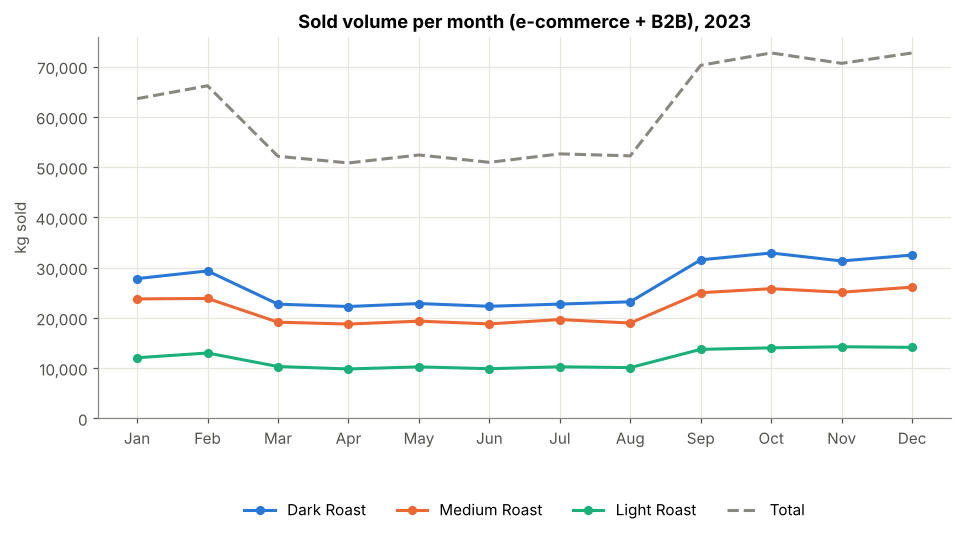

month,1,2,3,4,5,6,7,8,9,10,11,12
Product,,,,,,,,,,,,
Dark Roast,"27,802.00","29,326.00","22,710.00","22,248.00","22,838.00","22,290.00","22,726.00","23,185.00","31,538.00","32,898.00","31,312.00","32,490.00"
Medium Roast,"23,758.00","23,852.00","19,128.00","18,754.00","19,332.00","18,785.00","19,650.00","18,957.00","24,994.00","25,796.00","25,088.00","26,104.00"
Light Roast,"12,050.00","12,997.00","10,304.00","9,820.00","10,234.00","9,867.00","10,246.00","10,090.00","13,721.00","14,018.00","14,241.00","14,117.00"
Total,"63,611.00","66,176.00","52,141.00","50,822.00","52,404.00","50,942.00","52,623.00","52,232.00","70,253.00","72,712.00","70,642.00","72,710.00"


In [19]:
sales_month = sales_kg.unstack(level=0)[ROASTS]

fig, ax = plt.subplots()
for p in ROASTS:
    ax.plot(sales_month.index, sales_month[p], color=ROAST_COLORS[p], marker='o', markersize=5, label=p)
ax.plot(sales_month.index, sales_month.sum(axis=1), color=GREY, linestyle='--', label='Total')
ax.set_xticks(range(1, 13), MONTH_ABBR)
ax.yaxis.set_major_formatter(thousands)
ax.set_ylabel('kg sold')
ax.set_ylim(0)
ax.set_title('Sold volume per month (e-commerce + B2B), 2023')
ax.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.3))
plt.show()

sales_month.assign(Total=sales_month.sum(axis=1)).round(0).T

**Interpretation:** Demand has two clear levels: from March to August sales are around 51–53 tonnes per month, while September to December are at 70–73 tonnes (peak October: 72,712 kg). That is **~43% more** than in the low season; January/February are in between (64–66 tonnes). All three roast types follow the same pattern. This is crucial for the CEO: growth will hit the **autumn peak** first, because demand is already highest then. **Next step:** find out whether the peak comes from more orders or from bigger orders.

### 4.3 What drives the peak months: more orders or bigger orders?
**What:** per month the average number of orders per day and the average order value.
**Why:** if the number of orders stays the same but orders get bigger, the effect is different (more coffee, but not more boxes and parcels) than when there are more orders.

In [20]:
monthly_orders = ecom.groupby('month').agg(orders=('Value', 'size'),
                                            avg_order_value=('Value', 'mean'),
                                            avg_kg_per_order=('kg', 'mean'))
monthly_orders['orders_per_day'] = monthly_orders['orders'] / ecom.groupby('month')['Order date'].nunique()
monthly_orders.round(2).T

month,1,2,3,4,5,6,7,8,9,10,11,12
orders,"20,413.00","18,438.00","20,413.00","19,755.00","20,414.00","19,755.00","20,413.00","20,414.00","19,755.00","20,413.00","19,755.00","20,414.00"
avg_order_value,73.97,86.95,61.59,61.99,61.93,62.10,62.14,61.73,86.26,86.44,86.82,86.35
avg_kg_per_order,3.00,3.52,2.49,2.51,2.51,2.51,2.51,2.50,3.49,3.50,3.51,3.50
orders_per_day,658.48,658.50,658.48,658.50,658.52,658.50,658.48,658.52,658.50,658.48,658.50,658.52


**Interpretation:** The number of orders per day is exactly the same all year (~658.5). So the seasonal peak comes entirely from customers placing **bigger orders**: in the low season on average 2.5 kg and €62 per order, in the peak (Feb, Sep–Dec) 3.5 kg and €86–87 per order. For operations this means that in the peak more coffee must be roasted and packed, but not more parcels shipped. When growth comes from **new customers**, however, the number of orders increases, and so do parcels, boxes and PostNL costs. **Next step:** look at the product and bag mix.

### 4.4 Product mix and bag mix
**What:** the share of each roast type and each bag size in e-commerce kg and revenue.
**Why:** the mix decides which machine is used most (P60 = Medium, Px120 = Dark + Light) and how many bags of each size are needed.

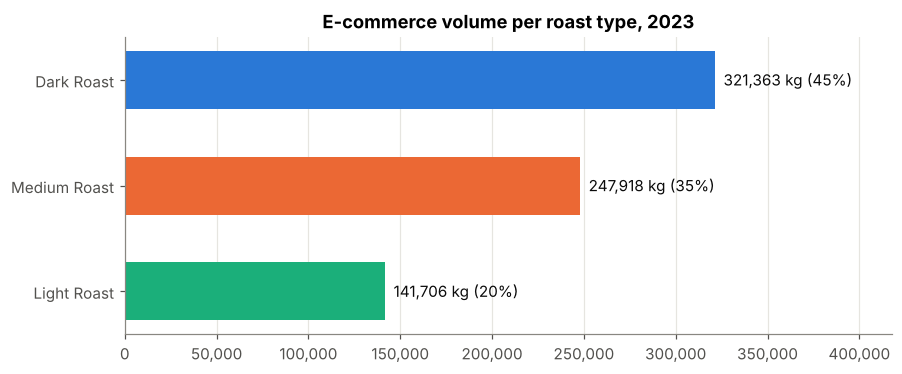

In [21]:
mix = ecom.groupby(['Product', 'Bag type']).agg(kg=('kg', 'sum'), revenue=('Value', 'sum'), bags=('Quantity', 'sum'))
mix.index = mix.index.set_levels(['1 kg', '0.5 kg'], level=1)
mix['share kg'] = mix['kg'] / mix['kg'].sum()

fig, ax = plt.subplots(figsize=(9, 3.5))
by_roast = ecom.groupby('Product')['kg'].sum().reindex(ROASTS)
bars = ax.barh(by_roast.index, by_roast.values, color=[ROAST_COLORS[p] for p in ROASTS], height=0.55)
for bar, v in zip(bars, by_roast.values):
    ax.text(v, bar.get_y() + bar.get_height() / 2, f'  {v:,.0f} kg ({v / by_roast.sum():.0%})', va='center', color='#0b0b0b')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(thousands)
ax.set_xlim(0, by_roast.max() * 1.3)
ax.set_title('E-commerce volume per roast type, 2023')
ax.grid(axis='y', visible=False)
plt.show()

mix.style.format({'kg': '{:,.0f}', 'revenue': '€{:,.0f}', 'bags': '{:,.0f}', 'share kg': '{:.1%}'})

**Interpretation:** Dark Roast is the largest type (321 tonnes, 45% of e-commerce volume), followed by Medium (35%) and Light (20%). 70% of the kilograms are sold in 0.5 kg bags: more than 994,000 bags, compared with 213,000 bags of 1 kg. Because Dark and Light are both roasted on the Px120, that machine handles ~65% of the volume. The high share of small bags means twice as many filling and packing actions per kg. **Next step:** look at where the customers are.

### 4.5 Where are the customers?
**What:** number of e-commerce orders per province, and B2B customers per city.
**Why:** the spread matters for delivery (PostNL costs are the same everywhere, the own B2B truck is not) and for growth opportunities in provinces with low sales. In the storytelling phase this can become a map (Folium).

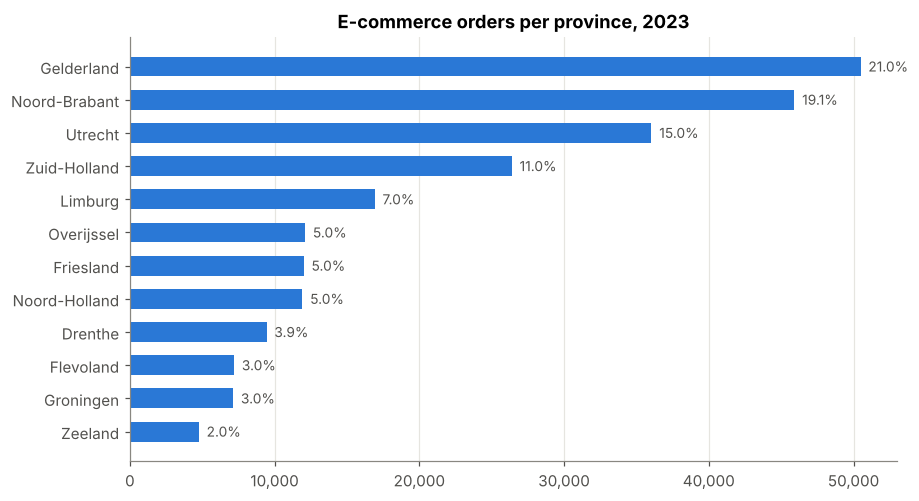

,customers,deliveries,kg
City,,,
Utrecht,6,78,"4,785.00"
The Hague,3,39,"2,351.00"
Rotterdam,3,39,"2,214.00"
Amsterdam,3,39,"2,207.00"
Arnhem,2,26,"1,544.00"
Nijmegen,2,26,"1,526.00"
s-Hertogenbosch,1,13,828.00
Amersfoort,1,13,825.00


In [22]:
prov = ecom.groupby('Ship to (province)').agg(orders=('Value', 'size'), revenue=('Value', 'sum')).sort_values('orders')
prov['share'] = prov['orders'] / prov['orders'].sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(prov.index, prov['orders'], color='#2a78d6', height=0.6)
for i, (v, s) in enumerate(zip(prov['orders'], prov['share'])):
    ax.text(v, i, f'  {s:.1%}', va='center', color='#52514e', fontsize=9)
ax.xaxis.set_major_formatter(thousands)
ax.set_title('E-commerce orders per province, 2023')
ax.grid(axis='y', visible=False)
plt.show()

b2b.groupby('City').agg(customers=('Customer', 'nunique'), deliveries=('Customer', 'size'),
                        kg=('kg', 'sum')).sort_values('kg', ascending=False)

**Interpretation:** Customers are mainly in the east and centre of the country: Gelderland (21%), Noord-Brabant (19%) and Utrecht (15%) together account for 55% of orders. Noord-Holland (5%) and Zuid-Holland (11%) are surprisingly small given their population, so there is growth potential there. B2B customers, on the other hand, are mainly in the Randstad (Utrecht 6 customers, Amsterdam/Rotterdam/The Hague 3 each). For the storytelling, this is a good candidate for a map (Folium). **Next step:** look at the B2B delivery pattern.

### 4.6 B2B customers: delivery pattern
**What:** we look at the dates of B2B deliveries and the quantity per customer.
**Why:** B2B is delivered with the company's own truck. The delivery rhythm decides how much transport capacity is needed when new B2B customers are added (no new customers have been accepted since early 2023).

In [23]:
print('Unique delivery dates:', b2b['Delivery date'].nunique())
print('Days between deliveries:', b2b['Delivery date'].drop_duplicates().sort_values().diff().dt.days.value_counts().to_dict())
print('Deliveries per customer:', b2b['Customer'].value_counts().unique())
print(f"Avg kg per delivery: {b2b['kg'].mean():.1f}  (min {b2b['kg'].min():.0f}, max {b2b['kg'].max():.0f})")
print(f"B2B transport cost per kg: EUR {b2b['Shipping costs'].sum() / b2b['kg'].sum():.2f}  "
      f"vs e-com shipping cost per kg: EUR {ecom['Shipping costs'].sum() / ecom['kg'].sum():.2f}")

Unique delivery dates: 13
Days between deliveries: {28.0: 9, 30.0: 2, 31.0: 1}
Deliveries per customer: [13]
Avg kg per delivery: 59.6  (min 40, max 80)
B2B transport cost per kg: EUR 1.26  vs e-com shipping cost per kg: EUR 2.28


**Interpretation:** All 15 B2B customers receive exactly 13 deliveries per year, all on the same day, usually every 28 days. Each delivery is 40–80 kg (on average 59.6 kg) of Medium Roast in 1 kg bags, so about 900 kg goes out per trip. Transport costs per kg are €1.26 for B2B, compared with €2.28 for e-commerce (PostNL). So B2B is cheaper to deliver per kg. However, demand comes all at once: on one day per month ~900 kg of Medium Roast must be ready. **Next step:** measure e-commerce delivery reliability.

### 4.7 Delivery: is the next-day promise kept?
**What:** for each order we calculate the **promised** delivery date (the first working day after the order date, taking weekends and public holidays into account) and compare it with the actual delivery date.
**Why:** 'next-day delivery' is a key promise of the webshop. If it already fails with stable demand, it becomes a big risk when the company grows.
We derived the public holidays from the data: no deliveries took place on these working days (e.g. Good Friday, Easter, King's Day, Ascension Day, Whit Monday, Christmas).

In [24]:
all_workdays = pd.bdate_range('2023-01-02', '2024-01-05')
delivery_days = set(ecom['Delivery date'].dt.normalize())
holidays = [d for d in all_workdays if d not in delivery_days and d <= ecom['Delivery date'].max()]
print('Workdays without any delivery (treated as holidays):', [d.strftime('%d-%m-%Y') for d in holidays])

hol = np.array(holidays, dtype='datetime64[D]')
next_day = (ecom['Order date'] + pd.Timedelta(days=1)).values.astype('datetime64[D]')
ecom['promised_date'] = pd.to_datetime(np.busday_offset(next_day, 0, roll='forward', holidays=hol))
ecom['days_late'] = np.busday_count(ecom['promised_date'].values.astype('datetime64[D]'),
                                    ecom['Delivery date'].values.astype('datetime64[D]'), holidays=hol)
ecom['on_time'] = ecom['days_late'] <= 0

print(f"\nOn-time delivery (next working day): {ecom['on_time'].mean():.1%}")
ecom['days_late'].value_counts().sort_index().rename('orders').to_frame().T

Workdays without any delivery (treated as holidays): ['07-04-2023', '10-04-2023', '27-04-2023', '18-05-2023', '29-05-2023', '25-12-2023', '26-12-2023', '01-01-2024']

On-time delivery (next working day): 92.1%


days_late,0,1
orders,221301,19051


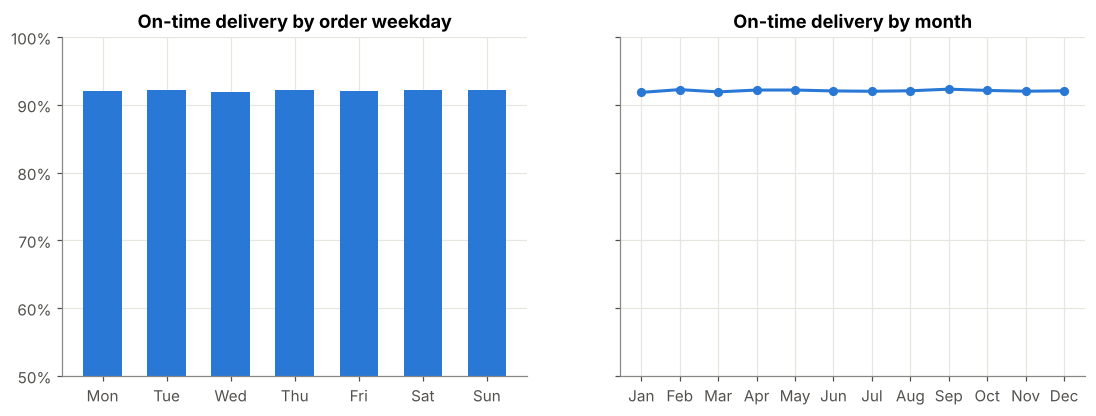

Order date,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
on-time by weekday,92.0%,92.1%,91.9%,92.2%,92.0%,92.1%,92.2%


In [25]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
otd_wd = ecom.groupby(ecom['Order date'].dt.day_name())['on_time'].mean().reindex(weekday_order)
otd_m = ecom.groupby('month')['on_time'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].bar(otd_wd.index.str[:3], otd_wd.values, color='#2a78d6', width=0.6)
axes[0].set_title('On-time delivery by order weekday')
axes[1].plot(otd_m.index, otd_m.values, color='#2a78d6', marker='o', markersize=5)
axes[1].set_xticks(range(1, 13), MONTH_ABBR)
axes[1].set_title('On-time delivery by month')
for ax in axes:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0.5, 1.0)
plt.show()

pd.DataFrame({'on-time by weekday': otd_wd}).T.style.format('{:.1%}')

**Interpretation:** 92.1% of orders are delivered on the promised day; the other 19,051 orders (7.9%) arrive exactly one working day late, never later. Remarkably, this percentage is almost the same everywhere: per weekday (91.9–92.2%), per month (91.8–92.3%), per province and per product. So the delay is **not** caused by busy peak months; it is structural, for example orders that come in after a cut-off time, or PostNL itself. The data has no order time, so we cannot confirm this. For the CEO this means ~1 in 13 customers does not get the next-day promise, and with growth that becomes more customers in absolute numbers. **Next step:** look at shipping costs. On-time delivery becomes a KPI with a target of, for example, ≥95%.

### 4.8 Shipping costs: what does e-commerce delivery cost the company?
**What:** we compare the shipping costs the company pays to PostNL with the shipping fees customers pay.
**Why:** because of the free-shipping threshold, the company pays part of the delivery costs itself. When the company grows, these costs grow with the number of orders.

In [26]:
ship = pd.Series({
    'Shipping costs paid to PostNL': ecom['Shipping costs'].sum(),
    'Delivery fees paid by customers': ecom['Delivery fee'].sum(),
})
ship['Net shipping cost for company'] = ship.iloc[0] - ship.iloc[1]
ship['Net shipping cost as % of e-com revenue'] = ship['Net shipping cost for company'] / ecom['Value'].sum() * 100
ship.round(2)

Shipping costs paid to PostNL             1,622,376.00
Delivery fees paid by customers             599,143.05
Net shipping cost for company             1,023,232.95
Net shipping cost as % of e-com revenue           5.83
dtype: float64

**Interpretation:** The company pays PostNL €1.62 million (€6.75 per order) and receives €0.60 million in shipping fees from customers. So shipping costs the company **€1.02 million net, or 5.8% of e-commerce revenue**. Every new customer who orders below €55 costs €1.80 net per order in shipping; a customer above €55 costs the full €6.75. When the company grows through new customers, these costs grow at the same rate. **Next step:** look at production: can the roasters handle demand?

### 4.9 Roasting: production per machine
**What:** roasted kg per machine per month.
**Why:** the roasters are the core of production. We want to see whether output per machine is stable or changes, and whether it follows the demand pattern from 4.2.

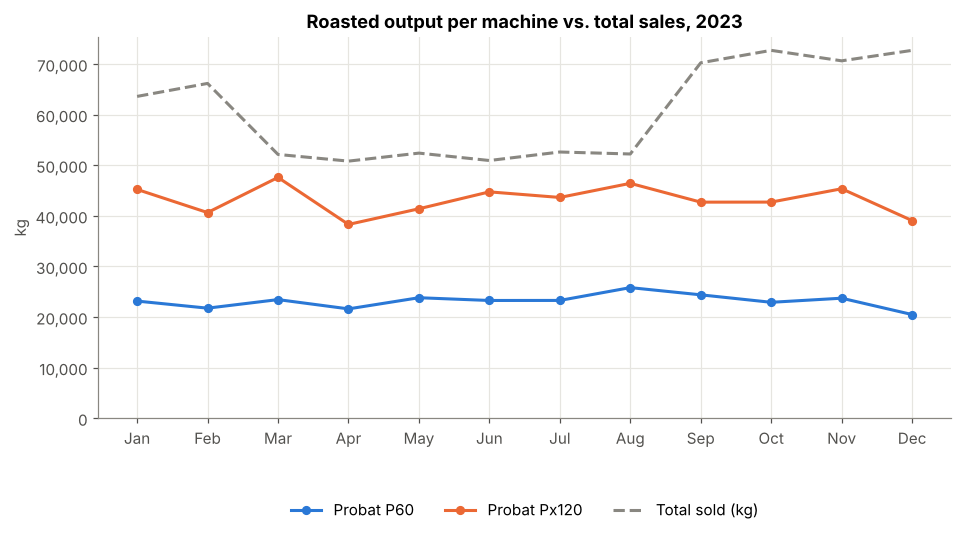

month,1,2,3,4,5,6,7,8,9,10,11,12
Machine,,,,,,,,,,,,
Probat P60,"23,162.00","21,765.00","23,455.00","21,621.00","23,826.00","23,283.00","23,292.00","25,823.00","24,399.00","22,922.00","23,733.00","20,504.00"
Probat Px120,"45,227.00","40,654.00","47,598.00","38,308.00","41,405.00","44,746.00","43,642.00","46,432.00","42,714.00","42,726.00","45,360.00","39,074.00"
Total,"68,390.00","62,419.00","71,052.00","59,929.00","65,231.00","68,029.00","66,934.00","72,256.00","67,113.00","65,648.00","69,093.00","59,578.00"


In [27]:
prod_machine = roast.pivot_table(index='month', columns='Machine', values='roasted_kg_out', aggfunc='sum')

fig, ax = plt.subplots()
for m in prod_machine.columns:
    ax.plot(prod_machine.index, prod_machine[m], color=MACHINE_COLORS[m], marker='o', markersize=5, label=m)
ax.plot(sales_month.index, sales_month.sum(axis=1), color=GREY, linestyle='--', label='Total sold (kg)')
ax.set_xticks(range(1, 13), MONTH_ABBR)
ax.yaxis.set_major_formatter(thousands)
ax.set_ylim(0)
ax.set_ylabel('kg')
ax.set_title('Roasted output per machine vs. total sales, 2023')
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.3))
plt.show()

prod_machine.assign(Total=prod_machine.sum(axis=1)).round(0).T

**Interpretation:** Production is fairly flat during the year: the P60 roasts 20.5–25.8 tonnes per month and the Px120 38.3–47.6 tonnes, together 59.6–72.3 tonnes. Demand varies much more (51–73 tonnes). So the company produces 'to stock' at a flat level: from March to August it roasts more than it sells, and from September to December less. For the CEO this means the autumn peak is already partly covered from stock. **Next step:** find out how much room is left on the machines.

### 4.10 Roasting: how full are the machines?
**What:** per machine we calculate (a) the occupied machine time per day (`batches per day × (setup + run time)`) and (b) the actual throughput in kg of green beans per hour, compared with the capacity from the case (P60: 215 kg/h, Px120: 480 kg/h).
**Why:** this is the most important question for growth: how much room is left on the roasters? We do not include cooling time in machine time, because cooling happens in the cooling tray while the next batch can already be roasted (assumption, to be checked with the company).

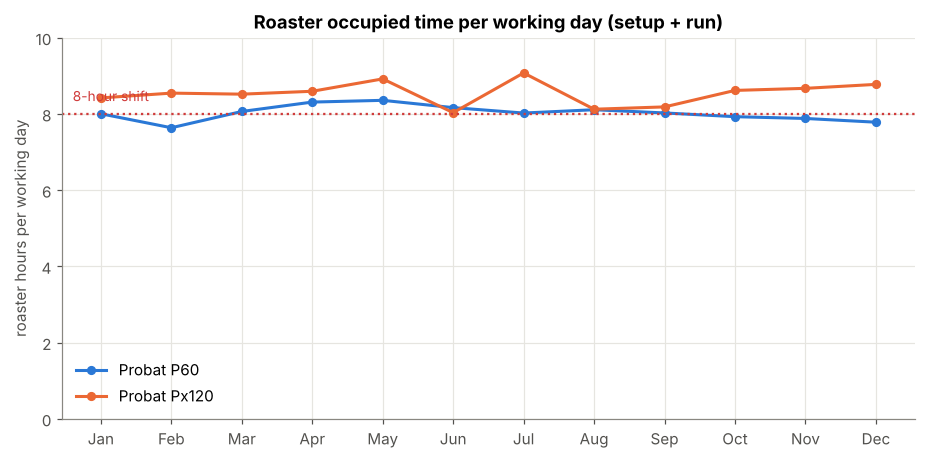

Machine,Probat P60,Probat Px120
mean,8.02,8.54
min,7.64,8.03
max,8.36,9.07


In [28]:
roast['roaster_min_per_batch'] = roast['Setup time p/batch'] + roast['Run time p/batch (m)']
roast['roaster_min_per_day'] = roast['Number of batches per day'] * roast['roaster_min_per_batch']
roast['packing_min_per_day'] = roast['Number of batches per day'] * roast['Packing time p/batch']

machine_day = roast.groupby(['Machine', 'month'])[['roaster_min_per_day', 'packing_min_per_day']].sum()
machine_hours = (machine_day['roaster_min_per_day'] / 60).unstack(level=0)

fig, ax = plt.subplots()
for m in machine_hours.columns:
    ax.plot(machine_hours.index, machine_hours[m], color=MACHINE_COLORS[m], marker='o', markersize=5, label=m)
ax.axhline(8, color='#d03b3b', linestyle=':', linewidth=1.5)
ax.text(0.6, 8.25, '8-hour shift', color='#d03b3b', va='bottom', fontsize=9)
ax.set_xticks(range(1, 13), MONTH_ABBR)
ax.set_ylim(0, 10)
ax.set_ylabel('roaster hours per working day')
ax.set_title('Roaster occupied time per working day (setup + run)')
ax.legend(loc='lower left')
plt.show()

machine_hours.describe().loc[['mean', 'min', 'max']].round(2)

In [29]:
CAPACITY = {'Probat P60': 215, 'Probat Px120': 480}   # kg/h, from the case
MAX_BATCH = {'Probat P60': 60, 'Probat Px120': 120}   # kg, from the case

cap = roast.groupby('Machine').agg(batches=('batches', 'sum'), green_kg=('green_kg_in', 'sum'),
                                   roaster_min=('roaster_min_per_batch', 'mean'),
                                   load_kg=('Load weight p/batch', 'mean'))
cap['batches_per_hour'] = 60 / cap['roaster_min']
cap['actual kg/h'] = cap['load_kg'] * cap['batches_per_hour']
cap['rated kg/h'] = cap.index.map(CAPACITY)
cap['throughput vs rated'] = cap['actual kg/h'] / cap['rated kg/h']
cap['batch fill vs max'] = cap['load_kg'] / cap.index.map(MAX_BATCH)
cap.style.format({'batches': '{:,.0f}', 'green_kg': '{:,.0f}', 'roaster_min': '{:.1f}', 'load_kg': '{:.1f}',
                  'batches_per_hour': '{:.2f}', 'actual kg/h': '{:.0f}', 'rated kg/h': '{:.0f}',
                  'throughput vs rated': '{:.0%}', 'batch fill vs max': '{:.0%}'})

,batches,green_kg,roaster_min,load_kg,batches_per_hour,actual kg/h,rated kg/h,throughput vs rated,batch fill vs max
Machine,,,,,,,,,
Probat P60,"6,090","333,821",20.1,54.9,2.99,164,215,76%,91%
Probat Px120,"5,748","632,809",22.1,110.0,2.72,299,480,62%,92%


**Interpretation:** Both roasters are already fully occupied on a working day: the P60 on average 8.0 hours per day (7.6–8.4) and the Px120 even 8.5 hours (8.0–9.1). With one 8-hour shift there is **no spare roasting capacity**; the Px120 probably already runs with overtime. Actual throughput is 164 kg/h (P60, 76% of the stated 215 kg/h) and 299 kg/h (Px120, only 62% of 480 kg/h). This gap comes from setup time (on average ~5 minutes per batch, on a cycle of 20–22 minutes) and from batches being filled to only ~91–92%. For the growth decision this is the most important signal: **growth is only possible with extra hours (second shift / weekends) or higher throughput per hour** (less setup time, e.g. longer runs of one roast type on the Px120). **Next step:** check whether the packing line shows the same picture.

### 4.11 Packing: how full is the packing line?
**What:** packing time per day (`batches per day × packing time per batch`, for both machines together, because there is one fully automated packing line).
**Why:** if the packing line is already full, the bottleneck moves from the roasters to the packing line.

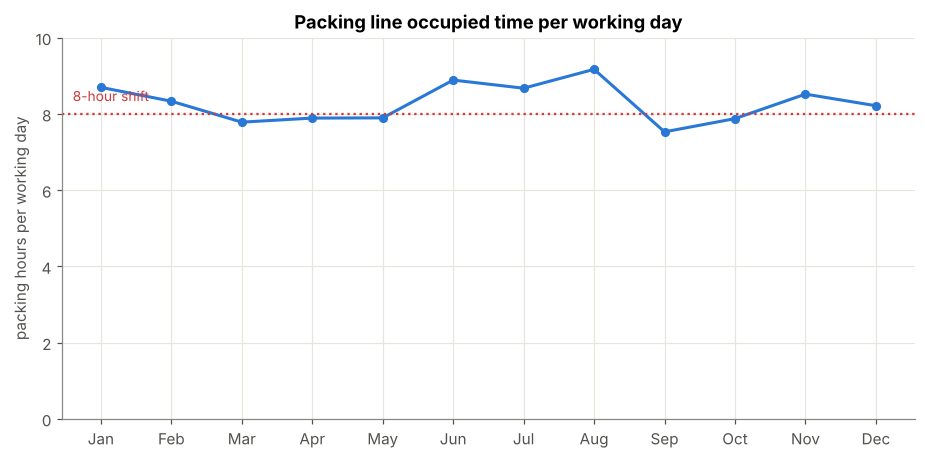

mean   8.29
min    7.53
max    9.17
Name: packing_min_per_day, dtype: float64

In [30]:
packing_hours = machine_day['packing_min_per_day'].groupby(level='month').sum() / 60

fig, ax = plt.subplots()
ax.plot(packing_hours.index, packing_hours.values, color='#2a78d6', marker='o', markersize=5, label='Packing line')
ax.axhline(8, color='#d03b3b', linestyle=':', linewidth=1.5)
ax.text(0.6, 8.25, '8-hour shift', color='#d03b3b', va='bottom', fontsize=9)
ax.set_xticks(range(1, 13), MONTH_ABBR)
ax.set_ylim(0, 10)
ax.set_ylabel('packing hours per working day')
ax.set_title('Packing line occupied time per working day')
plt.show()

packing_hours.describe()[['mean', 'min', 'max']].round(2)

**Interpretation:** The packing line is also occupied on average 8.3 hours per working day, with peaks up to 9.2 hours. So there is no room here within one shift either. Notably, a Px120 batch needs 12–16 minutes of packing time, compared with 6–9 minutes for a P60 batch. That makes sense for a batch that is twice as big, but it makes the packing line just as critical as the roasters. For the CEO this means that an extra roaster or a second roasting shift alone is not enough: the packing line must scale up as well. **Next step:** look at quality and weight loss.

### 4.12 Quality: rejected batches and weight loss
**What:** per roast type the reject rate (`rejected batches / batches`) and the reasons, plus the weight loss during roasting (`1 − final weight / load weight`).
**Why:** rejects cost beans and machine time, and machine time becomes scarce when the company grows. Weight loss decides how many green beans must be bought per kg of coffee sold.

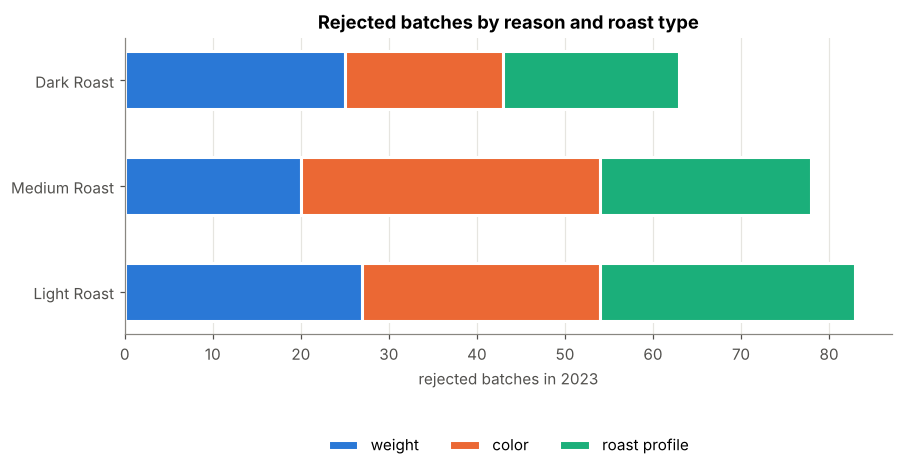

,batches,rejected,reject rate,weight loss,kg green per kg good output
Product,,,,,
Dark Roast,"4,076",63,1.55%,19.8%,1.267
Medium Roast,"6,090",78,1.28%,16.8%,1.217
Light Roast,"1,672",83,4.96%,14.1%,1.225


In [31]:
qc = roast.groupby('Product').agg(batches=('batches', 'sum'),
                                  rejected=('Total rejected batches p/month', 'sum'),
                                  weight=('QC fail/ Weight', 'sum'),
                                  color=('QC fail/ Color', 'sum'),
                                  roast_profile=('QC fail/ Roast profile', 'sum'),
                                  load=('green_kg_in', 'sum'), out=('roasted_kg_out', 'sum')).reindex(ROASTS)
qc['reject rate'] = qc['rejected'] / qc['batches']
qc['weight loss'] = 1 - qc['out'] / qc['load']
qc['kg green per kg good output'] = qc['load'] / (qc['out'] * (1 - qc['reject rate']))

fig, ax = plt.subplots(figsize=(9, 3.5))
reasons = ['weight', 'color', 'roast_profile']
reason_colors = ['#2a78d6', '#eb6834', '#1baf7a']
left = np.zeros(len(qc))
for r, c in zip(reasons, reason_colors):
    ax.barh(qc.index, qc[r], left=left, color=c, height=0.55, label=r.replace('_', ' '), edgecolor='white', linewidth=2)
    left += qc[r].values
ax.invert_yaxis()
ax.set_xlabel('rejected batches in 2023')
ax.set_title('Rejected batches by reason and roast type')
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.45))
ax.grid(axis='y', visible=False)
plt.show()

qc[['batches', 'rejected', 'reject rate', 'weight loss', 'kg green per kg good output']].style.format(
    {'batches': '{:,.0f}', 'rejected': '{:.0f}', 'reject rate': '{:.2%}', 'weight loss': '{:.1%}', 'kg green per kg good output': '{:.3f}'})

**Interpretation:** Light Roast clearly stands out: 83 of 1,672 batches were rejected (**4.96%**), compared with 1.55% for Dark and 1.28% for Medium. For Light Roast the reasons are evenly spread (weight, colour, roast profile), so the problem is not in one single step. Weight loss during roasting is 14% (Light) to 20% (Dark), so each kg of approved coffee needs 1.22–1.27 kg of green beans. For the CEO: every rejected Light batch costs beans and ~20 minutes of capacity on the Px120, which is already full. Bringing the Light reject rate down to the level of Dark immediately frees up capacity. **Next step:** look at finished product stock.

### 4.13 Finished product stock and write-offs
**What:** stock of roasted coffee per type per month, the write-offs because of expiry (`EXP`) and the **coverage in weeks** (stock / average sales per week).
**Why:** too much stock of a fresh product means coffee gets thrown away; too little stock means growth cannot be absorbed. Expectation: write-offs happen in the months with the highest stock.

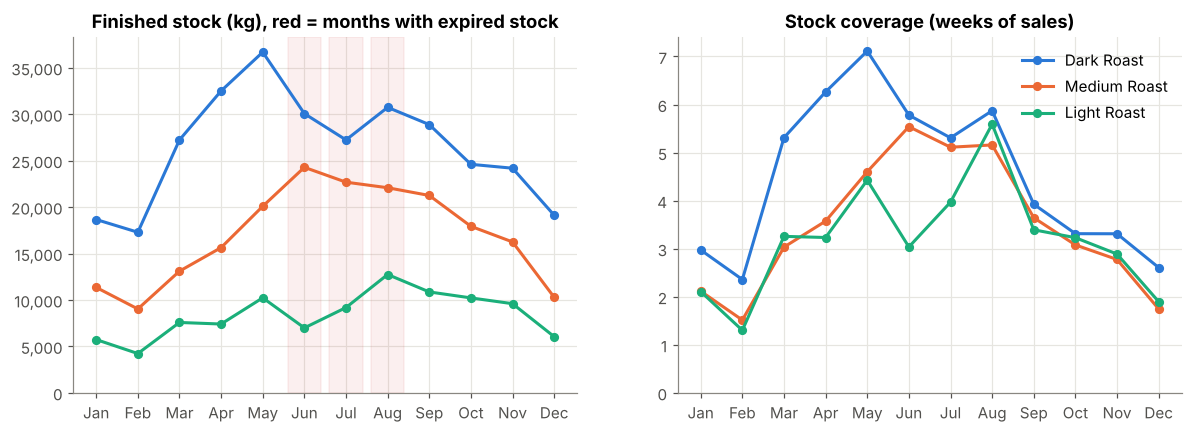

Expired finished coffee 2023: 48,000 kg  (sales value EUR 1,159,200)
= 6.6% of all kg sold


Product,Dark Roast,Medium Roast,Light Roast
month,,,
6,"15,000.00",-0.00,"6,000.00"
7,"10,000.00","5,000.00",-0.00
8,"5,000.00","7,000.00",-0.00


In [32]:
fin_stock = fin_inv.pivot_table(index='month', columns='Product', values='Stock level')[ROASTS]
fin_scrap = -fin_inv.pivot_table(index='month', columns='Product', values='Scrapped')[ROASTS]
weekly_sales = sales_month / (sales_month.index.map(lambda m: pd.Period(f'2023-{m:02d}').days_in_month) / 7).values[:, None]
coverage_weeks = fin_stock / weekly_sales

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for p in ROASTS:
    axes[0].plot(fin_stock.index, fin_stock[p], color=ROAST_COLORS[p], marker='o', markersize=5, label=p)
    axes[1].plot(coverage_weeks.index, coverage_weeks[p], color=ROAST_COLORS[p], marker='o', markersize=5, label=p)
for m in fin_scrap.index:
    if fin_scrap.loc[m].sum() > 0:
        axes[0].axvspan(m - 0.4, m + 0.4, color='#d03b3b', alpha=0.08)
axes[0].set_title('Finished stock (kg), red = months with expired stock')
axes[0].yaxis.set_major_formatter(thousands)
axes[1].set_title('Stock coverage (weeks of sales)')
for ax in axes:
    ax.set_xticks(range(1, 13), MONTH_ABBR)
    ax.set_ylim(0)
axes[1].legend(loc='upper right')
plt.show()

scrap_value = (-fin_inv['Scrapped'] * fin_inv['Unit price']).sum()
print(f'Expired finished coffee 2023: {fin_scrap.values.sum():,.0f} kg  (sales value EUR {scrap_value:,.0f})')
print(f'= {fin_scrap.values.sum() / sales_month.values.sum():.1%} of all kg sold')
fin_scrap.loc[fin_scrap.sum(axis=1) > 0]

**Interpretation:** Roasted coffee stock builds up from ~36 tonnes in January to 67 tonnes in May and falls back to ~35 tonnes in December. In May there were 7.1 weeks of Dark Roast sales in stock, while in February there was only 1.3 weeks of Light Roast. Right after the highest stock levels (June–August), **48,000 kg** of coffee had to be thrown away because it expired, with a sales value of **€1.16 million** (6.6% of all volume sold). So the flat production level (4.9) leads to far too much stock in summer and low coverage in autumn. For the CEO this is both a cost problem and a growth risk: the 'buffer' that covers the peak is partly lost. **Next step:** look at raw materials.

### 4.14 Raw materials: green bean stock per origin
**What:** stock and purchases per country of origin, and the **coverage in months** (stock / average monthly use).
**Why:** beans arrive by container from Costa Rica, Uganda and Colombia with long lead times. Low coverage means a risk of standstill; high coverage means money tied up in stock and a risk of write-offs (`EXP`).

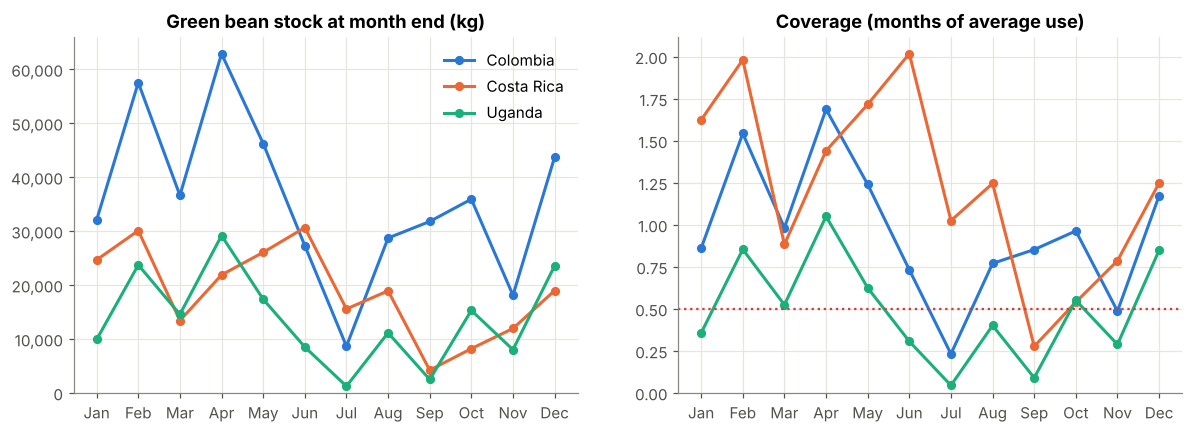

,purchased kg,avg use kg/month,min stock kg,month of min,min coverage (months),scrapped kg,price EUR/kg
Origin,,,,,,,
Colombia,"463,680.00","37,276.64","8,629.00",7,0.23,1680,6.95
Costa Rica,"181,440.00","15,179.82","4,194.00",9,0.28,0,11.50
Uganda,"342,720.00","27,776.36","1,226.00",7,0.04,3360,8.50


In [33]:
beans = raw_inv[raw_inv['Unit'] == 'Kg'].copy()
beans['Origin'] = beans['Product'].str.extract(r'COO (.*)\)')
bean_stock = beans.pivot_table(index='month', columns='Origin', values='Stock level')
bean_buy = beans.pivot_table(index='month', columns='Origin', values='Purchased')
bean_use = beans.pivot_table(index='month', columns='Origin', values='used')
bean_cov = bean_stock / bean_use.mean()

ORIGIN_COLORS = {'Colombia': '#2a78d6', 'Costa Rica': '#eb6834', 'Uganda': '#1baf7a'}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for o in bean_stock.columns:
    axes[0].plot(bean_stock.index, bean_stock[o], color=ORIGIN_COLORS[o], marker='o', markersize=5, label=o)
    axes[1].plot(bean_cov.index, bean_cov[o], color=ORIGIN_COLORS[o], marker='o', markersize=5, label=o)
axes[0].set_title('Green bean stock at month end (kg)')
axes[0].yaxis.set_major_formatter(thousands)
axes[1].set_title('Coverage (months of average use)')
axes[1].axhline(0.5, color='#d03b3b', linestyle=':', linewidth=1.5)
for ax in axes:
    ax.set_xticks(range(1, 13), MONTH_ABBR)
    ax.set_ylim(0)
axes[0].legend()
plt.show()

summary_beans = pd.DataFrame({
    'purchased kg': bean_buy.sum(), 'avg use kg/month': bean_use.mean(),
    'min stock kg': bean_stock.min(), 'month of min': bean_stock.idxmin(),
    'min coverage (months)': bean_cov.min(), 'scrapped kg': -beans.groupby('Origin')['Scrapped'].sum(),
    'price EUR/kg': beans.groupby('Origin')['Unit price'].first()})
summary_beans.round(2)

In [34]:
# Purchases come in fixed lots - which ones?
print('Purchase sizes used (kg):', sorted(beans.loc[beans['Purchased'] > 0, 'Purchased'].unique()))
print('Case: 1 container = 12 pallets x 12 bags x 70 kg =', 12 * 12 * 70, 'kg')

Purchase sizes used (kg): [np.int64(20160), np.int64(40320), np.int64(60480)]
Case: 1 container = 12 pallets x 12 bags x 70 kg = 10080 kg


**Interpretation:** Bean stock varies a lot and gets dangerously low for each origin: Uganda dropped to 1,226 kg in July, less than 5% of average monthly use (~27.8 tonnes), so roughly **one working day** of stock. Colombia (July, 0.23 month) and Costa Rica (September, 0.28 month) also dropped below half a month. At the same time, 5,040 kg of beans were written off as expired in May (Uganda and Colombia). Beans are bought in fixed lots of 20,160 kg (and multiples). According to the case one container is 10,080 kg, so every purchase is at least two containers (to be checked). For the CEO this means bean supply is already planned tightly; with growth there is a real risk of standstill. **Next step:** look at packaging stock.

### 4.15 Packaging materials
**What:** stock development of bags and shipping boxes, with purchase moments.
**Why:** packaging is cheap, but without packaging the whole line stops. We check whether stock ever gets critically low.

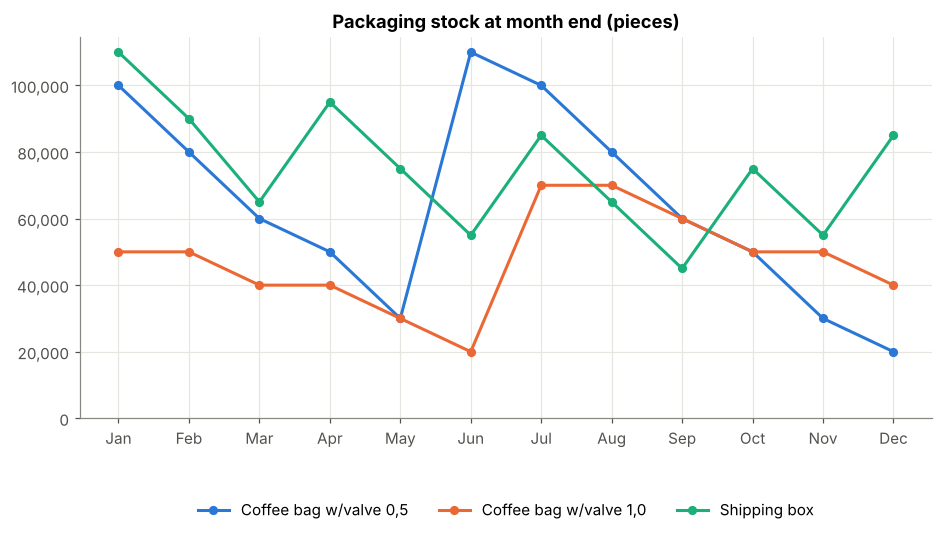

,Product,Month,Purchased,Scrapped,Reasoncode,Stock level
5,"Coffee bag w/valve 0,5",June,100000,-10000,DAM,110000
18,"Coffee bag w/valve 1,0",July,50000,0,NaN,70000
26,Shipping box,March,0,-5000,DAM,65000
27,Shipping box,April,50000,0,NaN,95000
30,Shipping box,July,50000,0,NaN,85000
33,Shipping box,October,50000,0,NaN,75000
35,Shipping box,December,50000,0,NaN,85000


In [35]:
pack = raw_inv[raw_inv['Unit'] == 'Piece'].pivot_table(index='month', columns='Product', values='Stock level')
PACK_COLORS = dict(zip(pack.columns, ['#2a78d6', '#eb6834', '#1baf7a']))

fig, ax = plt.subplots()
for c in pack.columns:
    ax.plot(pack.index, pack[c], color=PACK_COLORS[c], marker='o', markersize=5, label=c)
ax.set_xticks(range(1, 13), MONTH_ABBR)
ax.yaxis.set_major_formatter(thousands)
ax.set_ylim(0)
ax.set_title('Packaging stock at month end (pieces)')
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.3))
plt.show()

raw_inv[(raw_inv['Unit'] == 'Piece') & ((raw_inv['Purchased'] > 0) | (raw_inv['Scrapped'] < 0))][
    ['Product', 'Month', 'Purchased', 'Scrapped', 'Reasoncode', 'Stock level']]

**Interpretation:** Shipping boxes are restocked regularly (5× 50,000 pieces), while bags were bought only once (June: 100,000 × 0.5 kg; July: 50,000 × 1 kg). Packaging was written off twice because of damage (`DAM`: 10,000 bags in June, 5,000 boxes in March). Box stock never falls below 45,000 (more than two months). As shown in 3.6, the bag stock is not reliable enough to steer on. So packaging does not seem to be a direct growth bottleneck, but it is a data gap. **Next step:** summarise everything in a mass balance.

### 4.16 Mass balance for the whole year
**What:** we put the whole chain in one table: purchased beans → roasted → rejected → sold → written off.
**Why:** this shows the CEO at a glance where kilograms 'leak away', and it is the basis for a waterfall chart or Sankey diagram in the storytelling phase.

In [36]:
balance = pd.Series({
    'Green beans purchased': beans['Purchased'].sum(),
    'Green beans scrapped (EXP)': -beans['Scrapped'].sum(),
    'Green beans into roasters': roast['green_kg_in'].sum(),
    'Weight loss during roasting': roast['green_kg_in'].sum() - roast['roasted_kg_out'].sum(),
    'Roasted output (all batches)': roast['roasted_kg_out'].sum(),
    'Rejected batches (kg roasted)': roast['roasted_kg_out'].sum() - roast['good_kg_out'].sum(),
    'Good roasted output': roast['good_kg_out'].sum(),
    'Sold - e-commerce': ecom['kg'].sum(),
    'Sold - B2B': b2b['kg'].sum(),
    'Finished coffee expired': fin_scrap.values.sum(),
})
balance.to_frame('kg').style.format('{:,.0f}')

,kg
Green beans purchased,"987,840"
Green beans scrapped (EXP),"5,040"
Green beans into roasters,"966,630"
Weight loss during roasting,"170,958"
Roasted output (all batches),"795,671"
Rejected batches (kg roasted),"16,954"
Good roasted output,"778,718"
Sold - e-commerce,"710,988"
Sold - B2B,"16,280"
Finished coffee expired,"48,000"


**Interpretation:** In 2023 the company bought 988 tonnes of green beans, which fits the '±1,000 tonnes' from the case. Of this, 967 tonnes went into the roasters; 171 tonnes (17.7%) evaporated as normal weight loss. Of the 796 tonnes of roasted coffee, 17 tonnes were rejected and 48 tonnes later expired, and in the end 727 tonnes were sold. Together with the 5 tonnes of expired beans, that is **~70 tonnes of avoidable loss**, almost 10% of the volume sold. For the CEO this means some growth room can be found without extra machines: fewer rejects and less expired stock means more sellable coffee with the same capacity. **Next step:** summarise the findings and translate them into Data Preparation.

## 5. Summary of Data Understanding

### 5.1 Data quality → actions for Data Preparation

| # | Finding | Impact | Action in Data Preparation |
|---|---|---|---|
| 1 | `Bag type` is a code | Sales cannot be compared in kg | Convert: 1 = 1 kg, 2 = 0.5 kg (proven via price) |
| 2 | Product names spelled differently | Linking sheets fails | `.str.title()` on all product columns |
| 3 | Months as text in monthly sheets | No link with dates | Add month number |
| 4 | 119,101 identical e-com rows | Not an error: no order ID | Do **not** remove; report as limitation |
| 5 | `Reasoncode` empty | Means 'no write-off' | Fill with `NONE` |
| 6 | Rejected batches included in production | Production is overestimated | Base KPI on `good_kg_out` |
| 7 | 30,725 orders > €55 paid shipping | €152k charged wrongly | Create `fee_error` flag |
| 8 | Bag stock does not match sales | Cannot steer on bags | Check with client; exclude from KPIs |
| 9 | Opening stock Dec 2022 missing | January usage unknown | Exclude January from usage calculation |
| 10 | No order time, order ID or customer ID | No cut-off analysis or customer value | Report as limitation |

### 5.2 KPI candidates with 2023 baseline

| Process | KPI | 2023 |
|---|---|---|
| Sales | Revenue / volume | €17.98m / 727 tonnes (97.7% e-com) |
| Sales | Seasonal peak vs low season | +43% (73 vs 51 tonnes/month) |
| Delivery | On-time delivery (next working day) | 92.1% |
| Delivery | Net shipping cost as % of e-com revenue | 5.8% (€1.02m) |
| Delivery | Orders charged shipping wrongly | 12.8% |
| Roasting | Machine occupation per working day (8 h shift) | P60 8.0 h · Px120 8.5 h |
| Roasting | Throughput vs stated capacity | P60 76% · Px120 62% |
| Packing | Packing line occupation per working day | 8.3 h (max 9.2 h) |
| Quality | Batch reject rate | Dark 1.6% · Medium 1.3% · **Light 5.0%** |
| Finished stock | Coverage in weeks | 1.3 – 7.1 weeks |
| Finished stock | Expired coffee (EXP) | 48 tonnes = €1.16m sales value |
| Raw materials | Minimum green bean coverage | Uganda 0.04 month (July) |
| Chain | Avoidable loss (rejects + EXP) | ~70 tonnes ≈ 9.6% of volume sold |

### 5.3 First hypotheses about growth bottlenecks (to be tested in the next phases)

1. **Capacity:** the roasters and the packing line are already full within one 8-hour shift. Growth needs extra hours or higher throughput (less setup time, more runs of one roast type).
2. **Planning and stock:** a flat production level against seasonal demand creates expired stock in summer (48 tonnes) and low coverage in autumn. With growth, the autumn peak will be the first bottleneck.
3. **Purchasing:** bean stock already drops to ~1 day (Uganda); with more demand there is a risk of standstill without safety stock and better purchase planning.
4. **Quality:** the Light Roast reject rate (5%) costs capacity on the machine that is under the most pressure.
5. **Customer experience:** 7.9% late deliveries and 12.8% wrongly charged shipping fees damage a premium brand, and these numbers grow with new customers.

### 5.4 Next step
In **Data Preparation** we create one clean monthly table per product (demand, good output, stock, write-offs, bean usage) and a clean order table (kg, `on_time`, `fee_error`). With these we can **calculate scenarios** in the next phase (e.g. +10% / +20% growth): how many roasting and packing hours, beans and stock are needed per month? This answers the CEO's main question.